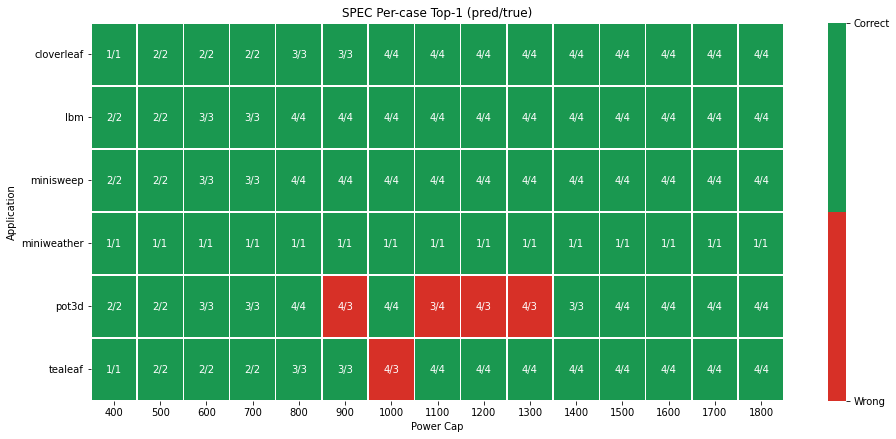

[written] /home/ac.zzheng/power/GPGPU/data/H100/fig1_heatmap_spec.png


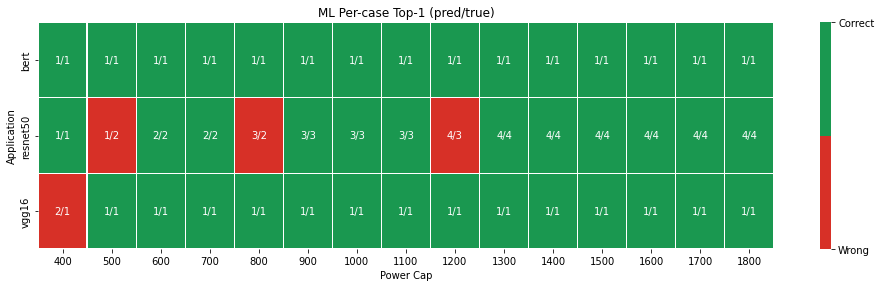

[written] /home/ac.zzheng/power/GPGPU/data/H100/fig1_heatmap_ml.png


In [5]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PRED_ROWS = Path("/home/ac.zzheng/power/GPGPU/data/H100/pred_rows.txt")

# app groups (edit if needed)
SUITE_APPS = {
    "SPEC": {"cloverleaf", "lbm", "minisweep", "miniweather", "pot3d", "tealeaf"},
    "ML": {"bert", "resnet50", "vgg16"},
}

pat = re.compile(
    r"^(?P<app>\S+)\s+cap=\s*(?P<cap>\d+)\s+pred_rank=\[(?P<pred>[0-9,\s]+)\]\s+true_rank=\[(?P<true>[0-9,\s]+)\]$"
)

rows = []
for ln in PRED_ROWS.read_text().splitlines():
    ln = ln.strip()
    m = pat.match(ln)
    if not m:
        continue
    app = m.group("app")
    cap = int(m.group("cap"))
    pred_top = int(m.group("pred").split(",")[0].strip())
    true_top = int(m.group("true").split(",")[0].strip())

    suite = None
    for s, apps in SUITE_APPS.items():
        if app in apps:
            suite = s
            break

    rows.append({
        "suite": suite if suite is not None else "UNKNOWN",
        "app": app,
        "cap": cap,
        "pred_top": pred_top,
        "true_top": true_top,
        "correct": int(pred_top == true_top),
        "label": f"{pred_top}/{true_top}",
    })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No rows parsed from pred_rows.txt")

def plot_suite(df_suite, suite_name):
    apps = sorted(df_suite["app"].unique())
    caps = sorted(df_suite["cap"].unique())

    mat = np.full((len(apps), len(caps)), np.nan)
    ann = np.empty((len(apps), len(caps)), dtype=object)

    for i, app in enumerate(apps):
        for j, cap in enumerate(caps):
            x = df_suite[(df_suite.app == app) & (df_suite.cap == cap)]
            if len(x) == 0:
                ann[i, j] = ""
                continue
            row = x.iloc[0]
            mat[i, j] = row["correct"]
            ann[i, j] = row["label"]

    plt.figure(figsize=(0.7 * len(caps) + 3, 0.7 * len(apps) + 2))
    ax = sns.heatmap(
        mat,
        cmap=sns.color_palette(["#d73027", "#1a9850"], as_cmap=True),
        vmin=0, vmax=1,
        cbar=True,
        linewidths=0.5, linecolor="white",
        annot=ann, fmt="",
        xticklabels=caps, yticklabels=apps,
    )
    ax.set_title(f"{suite_name} Per-case Top-1 (pred/true)")
    ax.set_xlabel("Power Cap")
    ax.set_ylabel("Application")
    cbar = ax.collections[0].colorbar
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Wrong", "Correct"])

    plt.tight_layout()
    out = PRED_ROWS.parent / f"fig1_heatmap_{suite_name.lower()}.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print("[written]", out)

for suite in ["SPEC", "ML"]:
    df_s = df[df["suite"] == suite]
    if len(df_s):
        plot_suite(df_s, suite)
